# Pitstop Analysis

Analyses official DHL pit stop stationary times and scores them against F1 Fantasy brackets.

**Data source:** DHL Fastest Pit Stop Award API (scraped via `scraping/scrape_dhl_pitstops.py`, cleaned to `data/interim/race_pitstops/`).

**F1 Fantasy pitstop scoring (constructors only):**
| Stationary time | Points |
|---|---|
| Over 3.0s | 0 |
| 2.50 - 3.00s | 2 |
| 2.20 - 2.49s | 5 |
| 2.00 - 2.19s | 10 |
| Under 2.0s | 20 |
| Fastest pitstop of the race | +5 |
| World record (<1.80s) | +15 |

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from app.config import INTERIM_PITSTOPS_DIR, PROCESSED_TARGETS_DIR
from app.data.scoring_rules import score_pitstop

## Load DHL pitstop data

Official stationary times from `data/interim/race_pitstops/`, scraped from the DHL Fastest Pit Stop Award API.

In [2]:
pitstops = pd.concat([
    pd.read_parquet(f) for f in sorted(INTERIM_PITSTOPS_DIR.glob('*.parquet'))
]).reset_index(drop=True)

print(f"Total pit stops: {len(pitstops)}")
print(f"Seasons: {sorted(pitstops['season'].unique())}")
print(f"Rounds per season: {pitstops.groupby('season')['round'].nunique().to_dict()}")
print(f"\nColumns: {pitstops.columns.tolist()}")
print(f"\nSample:")
pitstops.head(10)

Total pit stops: 4862
Seasons: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
Rounds per season: {2018: 20, 2019: 20, 2020: 8, 2021: 19, 2022: 20, 2023: 22, 2024: 24, 2025: 24, 2026: 6}

Columns: ['season', 'round', 'driver', 'lap', 'stationary_s', 'dhl_position', 'dhl_points', 'constructor_id', 'race_id']

Sample:


,season,round,driver,lap,stationary_s,dhl_position,dhl_points,constructor_id,race_id
0,2018,1,Verstappen,NaN,2.15,1,25,red_bull,2018_01
1,2018,1,Räikkönen,NaN,2.39,2,18,ferrari,2018_01
2,2018,1,Ricciardo,NaN,2.45,3,15,red_bull,2018_01
3,2018,1,Stroll,NaN,2.53,4,12,williams,2018_01
4,2018,1,Magnussen,NaN,2.72,5,10,haas,2018_01
5,2018,1,Hartley,NaN,2.80,6,8,toro_rosso,2018_01
6,2018,1,Leclerc,NaN,2.98,7,6,kick_sauber,2018_01
7,2018,1,Vettel,NaN,3.01,8,4,ferrari,2018_01
8,2018,1,Ocon,NaN,3.03,9,2,force_india,2018_01
9,2018,1,Hamilton,NaN,3.03,10,1,mercedes,2018_01


## Score pitstops against F1 Fantasy brackets

Find each constructor's fastest stop per race and score it using `score_pitstop()` from `scoring_rules.py`.

In [3]:
# find each constructor's fastest stop per race
constructor_best = (
    pitstops.sort_values('stationary_s')
    .groupby(['season', 'round', 'constructor_id'])
    .first()
    .reset_index()
    [['season', 'round', 'constructor_id', 'stationary_s']]
)

# identify fastest stop of each race
race_fastest = constructor_best.groupby(['season', 'round'])['stationary_s'].transform('min')
constructor_best['is_race_fastest'] = constructor_best['stationary_s'] == race_fastest

# score each constructor's best stop
constructor_best['pitstop_pts'] = constructor_best.apply(
    lambda r: score_pitstop(r['stationary_s'], r['is_race_fastest']), axis=1
)

# add race-level rank
constructor_best['race_time_rank'] = constructor_best.groupby(['season', 'round'])['stationary_s'].rank()

print(f"Constructor-race records: {len(constructor_best)}")
print(f"\nPitstop points distribution:")
print(constructor_best['pitstop_pts'].value_counts().sort_index().to_string())

Constructor-race records: 1621

Pitstop points distribution:
pitstop_pts
0     309
2     639
5     439
7       2
10    127
15     78
20      3
25     24


## Constructor pitstop consistency

How stable are pitstop times within a season? High consistency means recent rolling averages are predictive.

In [4]:
# fastest stop per constructor per race
best_per_race = (
    pitstops.sort_values('stationary_s')
    .groupby(['season', 'round', 'constructor_id'])
    .first()
    .reset_index()
)

# per-team within-season std (lower = more consistent/predictable)
team_season_stats = (
    best_per_race.groupby(['season', 'constructor_id'])['stationary_s']
    .agg(['mean', 'std', 'count'])
    .reset_index()
)
team_season_stats = team_season_stats[team_season_stats['count'] >= 5]

print("Within-season std of best stop time (lower = more consistent):\n")
pivot = team_season_stats.pivot(index='constructor_id', columns='season', values='std')
print(pivot.round(3).to_string())

print(f"\nOverall within-season std: {team_season_stats['std'].mean():.3f}s")
print(f"For context, the 10-pt bracket is only 0.20s wide (2.00-2.20s)")

Within-season std of best stop time (lower = more consistent):

season           2018   2019   2020   2021   2022   2023   2024   2025   2026
constructor_id                                                               
alfa_romeo        NaN  0.591  0.163  3.136  0.731  0.292    NaN    NaN    NaN
alphatauri        NaN    NaN  0.252  1.909  0.704  0.634    NaN    NaN    NaN
alpine            NaN    NaN    NaN  1.510  0.368  0.189  0.446  0.375  0.429
aston_martin      NaN    NaN    NaN  1.514  0.321  0.402  0.127  0.369  1.192
audi              NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN  5.531
cadillac          NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN  1.054
ferrari         0.372  0.239  0.290  0.269  1.443  0.220  0.326  0.186  0.593
force_india     1.188    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN
haas            0.301  0.596  1.240  0.285  3.180  0.942  0.262  0.286  0.275
kick_sauber     0.299    NaN    NaN    NaN    NaN    NaN  0.389  0.562    NaN


## Autocorrelation: does last race predict next race?

Check lag-1 correlation of pitstop times and points per constructor. High autocorrelation means a simple rolling average feature would work well.

In [5]:
# compute lag-1 autocorrelation per constructor (within season)
constructor_best_sorted = constructor_best.sort_values(['constructor_id', 'season', 'round'])

autocorrs_time = []
autocorrs_pts = []
for (team, season), group in constructor_best_sorted.groupby(['constructor_id', 'season']):
    if len(group) < 5:
        continue
    ac_time = group['stationary_s'].autocorr(lag=1)
    ac_pts = group['pitstop_pts'].autocorr(lag=1)
    if not pd.isna(ac_time):
        autocorrs_time.append({'constructor_id': team, 'season': season, 'autocorr_time': ac_time, 'autocorr_pts': ac_pts})

ac_df = pd.DataFrame(autocorrs_time)

print("Lag-1 autocorrelation of fastest stop time (per team-season):\n")
ac_pivot = ac_df.pivot(index='constructor_id', columns='season', values='autocorr_time')
print(ac_pivot.round(2).to_string())

print(f"\nMean autocorrelation (time): {ac_df['autocorr_time'].mean():.3f}")
print(f"Mean autocorrelation (pts):  {ac_df['autocorr_pts'].mean():.3f}")
print(f"\nInterpretation: {'weak' if abs(ac_df['autocorr_time'].mean()) < 0.3 else 'moderate' if abs(ac_df['autocorr_time'].mean()) < 0.5 else 'strong'} race-to-race correlation in stop times")

Lag-1 autocorrelation of fastest stop time (per team-season):

season          2018  2019  2020  2021  2022  2023  2024  2025  2026
constructor_id                                                      
alfa_romeo       NaN -0.10  0.03 -0.02 -0.03  0.24   NaN   NaN   NaN
alphatauri       NaN   NaN  0.30 -0.13 -0.02  0.02   NaN   NaN   NaN
alpine           NaN   NaN   NaN -0.11  0.26 -0.01  0.06  0.18  0.01
aston_martin     NaN   NaN   NaN  0.07 -0.06  0.17  0.46  0.38  0.57
audi             NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN -0.25
cadillac         NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN -0.03
ferrari        -0.22 -0.27 -0.22  0.17 -0.13  0.13 -0.22  0.19  0.07
force_india    -0.22   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN
haas            0.27 -0.05 -0.25 -0.05 -0.07  0.23  0.22 -0.15  0.36
kick_sauber     0.10   NaN   NaN   NaN   NaN   NaN  0.30 -0.17   NaN
mclaren         0.11 -0.11 -0.24 -0.12  0.34  0.23 -0.07 -0.34  0.87
mercedes       -0.10 -0.11  0.47 -0.22 -

c:\Users\gputs\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\gputs\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


## Rolling average as a predictor

Test how well a rolling N-race average of pitstop times predicts the next race's pitstop points. Compare different window sizes.

In [6]:
# for each constructor, compute rolling mean of best stop time, then score it
# and compare predicted points vs actual points

results = {}
for window in [3, 5, 8, 12]:
    cb = constructor_best.sort_values(['constructor_id', 'season', 'round']).copy()
    cb['rolling_mean_time'] = (
        cb.groupby('constructor_id')['stationary_s']
        .transform(lambda x: x.rolling(window, min_periods=max(2, window // 2)).mean().shift(1))
    )
    
    valid = cb.dropna(subset=['rolling_mean_time'])
    
    # score the rolling mean as if it were the actual time (excluding fastest bonus since unpredictable)
    valid['predicted_pts'] = valid['rolling_mean_time'].apply(lambda t: score_pitstop(t, False))
    valid['actual_pts_no_bonus'] = valid.apply(
        lambda r: score_pitstop(r['stationary_s'], False), axis=1
    )
    
    mae = (valid['predicted_pts'] - valid['actual_pts_no_bonus']).abs().mean()
    corr = valid['predicted_pts'].corr(valid['actual_pts_no_bonus'])
    exact_match = (valid['predicted_pts'] == valid['actual_pts_no_bonus']).mean()
    
    results[window] = {'MAE': mae, 'corr': corr, 'exact_bracket_match': exact_match, 'n': len(valid)}

results_df = pd.DataFrame(results).T
results_df.index.name = 'window'
print("Rolling average prediction accuracy (excl. fastest-stop bonus):\n")
print(results_df.round(3).to_string())
print(f"\nBaseline (always predict median points): MAE = {(constructor_best['pitstop_pts'].median() - constructor_best['pitstop_pts']).abs().mean():.3f}")

C:\Users\gputs\AppData\Local\Temp\ipykernel_28128\235548082.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['predicted_pts'] = valid['rolling_mean_time'].apply(lambda t: score_pitstop(t, False))
C:\Users\gputs\AppData\Local\Temp\ipykernel_28128\235548082.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['actual_pts_no_bonus'] = valid.apply(
C:\Users\gputs\AppData\Local\Temp\ipykernel_28128\235548082.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a D

Rolling average prediction accuracy (excl. fastest-stop bonus):

          MAE   corr  exact_bracket_match       n
window                                           
3       2.045  0.452                0.468  1585.0
5       1.979  0.467                0.467  1585.0
8       1.997  0.467                0.466  1549.0
12      2.030  0.453                0.464  1513.0

Baseline (always predict median points): MAE = 2.826


C:\Users\gputs\AppData\Local\Temp\ipykernel_28128\235548082.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['actual_pts_no_bonus'] = valid.apply(
C:\Users\gputs\AppData\Local\Temp\ipykernel_28128\235548082.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['predicted_pts'] = valid['rolling_mean_time'].apply(lambda t: score_pitstop(t, False))
C:\Users\gputs\AppData\Local\Temp\ipykernel_28128\235548082.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a D

## Team tier stability

Do the same teams consistently sit in the same scoring brackets? If teams are clustered into stable tiers, a categorical team-strength feature may work better than raw times.

Bracket distribution % per constructor (2023-2026):

bracket         <2.0s (20pt)  2.0-2.2s (10pt)  2.2-2.5s (5pt)  2.5-3.0s (2pt)  >3.0s (0pt)  expected_bracket_pts
constructor_id                                                                                                  
red_bull                10.5             27.6            39.5            17.1          5.3                   7.2
mclaren                  6.8             25.7            47.3            13.5          6.8                   6.6
ferrari                  4.0             26.7            50.7            14.7          4.0                   6.3
racing_bulls             0.0             22.6            49.1            20.8          7.5                   5.1
mercedes                 0.0              9.2            43.4            38.2          9.2                   3.9
alphatauri               0.0              4.5            54.5            31.8          9.1                   3.8
audi                     0.0             16

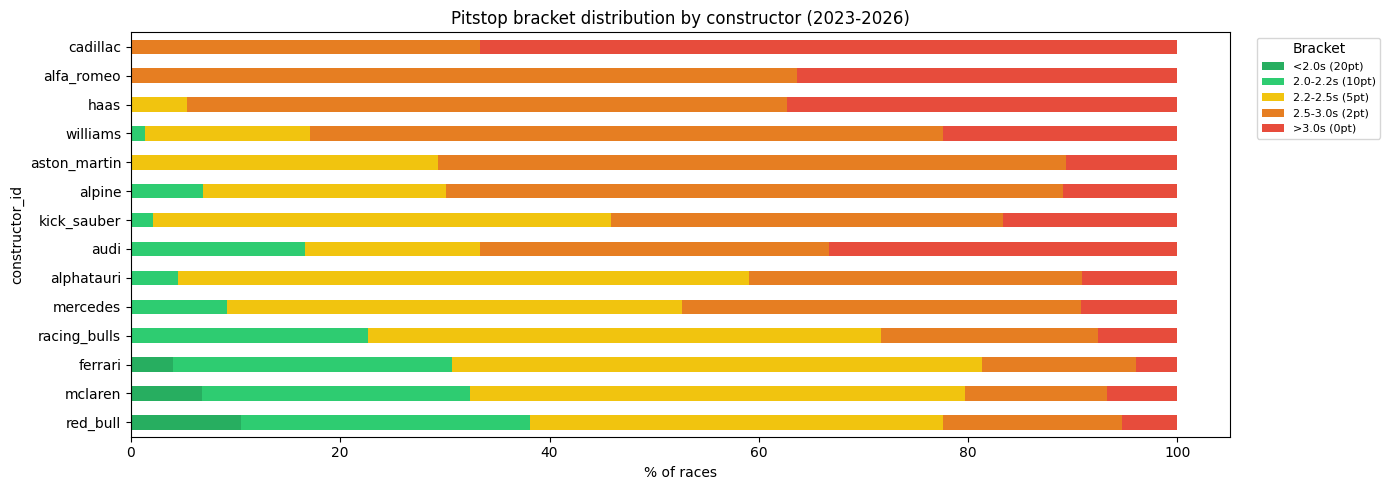

In [7]:
# bracket distribution per team (2023-2026, current era)
recent = constructor_best[constructor_best['season'] >= 2023].copy()

def bracket_label(t):
    if t < 2.0: return '<2.0s (20pt)'
    elif t < 2.2: return '2.0-2.2s (10pt)'
    elif t < 2.5: return '2.2-2.5s (5pt)'
    elif t < 3.005: return '2.5-3.0s (2pt)'
    else: return '>3.0s (0pt)'

recent['bracket'] = recent['stationary_s'].apply(bracket_label)

bracket_order = ['<2.0s (20pt)', '2.0-2.2s (10pt)', '2.2-2.5s (5pt)', '2.5-3.0s (2pt)', '>3.0s (0pt)']
team_bracket_pcts = (
    recent.groupby(['constructor_id', 'bracket']).size()
    .unstack(fill_value=0)
    .reindex(columns=bracket_order, fill_value=0)
)
team_bracket_pcts = team_bracket_pcts.div(team_bracket_pcts.sum(axis=1), axis=0) * 100

# sort by expected points (weighted average)
bracket_pts = {'<2.0s (20pt)': 20, '2.0-2.2s (10pt)': 10, '2.2-2.5s (5pt)': 5, '2.5-3.0s (2pt)': 2, '>3.0s (0pt)': 0}
team_bracket_pcts['expected_bracket_pts'] = sum(
    team_bracket_pcts[b] / 100 * pts for b, pts in bracket_pts.items()
)
team_bracket_pcts = team_bracket_pcts.sort_values('expected_bracket_pts', ascending=False)

print("Bracket distribution % per constructor (2023-2026):\n")
print(team_bracket_pcts.round(1).to_string())

fig, ax = plt.subplots(figsize=(14, 5))
colors = ['#27ae60', '#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']
team_bracket_pcts[bracket_order].plot(kind='barh', stacked=True, ax=ax, color=colors)
ax.set_xlabel('% of races')
ax.set_title('Pitstop bracket distribution by constructor (2023-2026)')
ax.legend(title='Bracket', bbox_to_anchor=(1.02, 1), fontsize=8)
plt.tight_layout()
plt.show()

## Fastest-stop bonus predictability

The +5 fastest-stop bonus is binary per race. How concentrated is it among top teams? If one team wins it >30% of the time, it's worth modelling as a probability.

In [8]:
# who wins the fastest stop per race?
fastest_winners = constructor_best[constructor_best['is_race_fastest']].copy()

# overall win rate
win_counts = fastest_winners.groupby('constructor_id').size().sort_values(ascending=False)
total_races = constructor_best.groupby(['season', 'round']).ngroups
win_pcts = (win_counts / total_races * 100).round(1)

print("Fastest pitstop wins (all seasons):\n")
for team, pct in win_pcts.items():
    print(f"  {team:20s}: {win_counts[team]:3d} wins ({pct}%)")

# recent era (2023+)
recent_fastest = fastest_winners[fastest_winners['season'] >= 2023]
recent_races = constructor_best[constructor_best['season'] >= 2023].groupby(['season', 'round']).ngroups
recent_wins = recent_fastest.groupby('constructor_id').size().sort_values(ascending=False)
recent_pcts = (recent_wins / recent_races * 100).round(1)

print(f"\nRecent era (2023-2026, {recent_races} races):\n")
for team, pct in recent_pcts.items():
    print(f"  {team:20s}: {recent_wins[team]:3d} wins ({pct}%)")

# is the fastest bonus team-predictable from rolling form?
cb = constructor_best.sort_values(['constructor_id', 'season', 'round']).copy()
cb['rolling_5_time'] = cb.groupby('constructor_id')['stationary_s'].transform(
    lambda x: x.rolling(5, min_periods=3).mean().shift(1)
)
valid = cb.dropna(subset=['rolling_5_time'])
valid['predicted_fastest'] = valid.groupby(['season', 'round'])['rolling_5_time'].transform('min') == valid['rolling_5_time']

tp = valid[valid['predicted_fastest'] & valid['is_race_fastest']].shape[0]
fp = valid[valid['predicted_fastest'] & ~valid['is_race_fastest']].shape[0]
fn = valid[~valid['predicted_fastest'] & valid['is_race_fastest']].shape[0]

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
print(f"\nPredicting fastest bonus from rolling-5 best avg:")
print(f"  Precision: {precision:.1%} (of predictions, how many correct)")
print(f"  Recall:    {recall:.1%} (of actual wins, how many predicted)")

Fastest pitstop wins (all seasons):

  red_bull            :  64 wins (39.3%)
  ferrari             :  33 wins (20.2%)
  mclaren             :  24 wins (14.7%)
  williams            :  17 wins (10.4%)
  kick_sauber         :   7 wins (4.3%)
  mercedes            :   6 wins (3.7%)
  racing_bulls        :   5 wins (3.1%)
  alpine              :   4 wins (2.5%)
  alfa_romeo          :   1 wins (0.6%)
  alphatauri          :   1 wins (0.6%)
  aston_martin        :   1 wins (0.6%)

Recent era (2023-2026, 76 races):

  red_bull            :  25 wins (32.9%)
  ferrari             :  23 wins (30.3%)
  mclaren             :  16 wins (21.1%)
  racing_bulls        :   5 wins (6.6%)
  kick_sauber         :   4 wins (5.3%)
  mercedes            :   2 wins (2.6%)
  alpine              :   1 wins (1.3%)

Predicting fastest bonus from rolling-5 best avg:
  Precision: 40.0% (of predictions, how many correct)
  Recall:    40.0% (of actual wins, how many predicted)


C:\Users\gputs\AppData\Local\Temp\ipykernel_28128\1856656131.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['predicted_fastest'] = valid.groupby(['season', 'round'])['rolling_5_time'].transform('min') == valid['rolling_5_time']


## Season-over-season trends

Are pitstop times getting faster over years? If so, bracket thresholds may need to be interpreted relative to season averages.

Season-level stats (fastest stop per constructor per race):

         mean  median    std   min
season                            
2018    2.805   2.690  0.626  1.97
2019    2.664   2.570  0.502  1.82
2020    2.814   2.690  0.668  1.86
2021    2.765   2.480  1.372  1.88
2022    2.983   2.710  1.268  2.09
2023    2.765   2.600  0.909  1.80
2024    2.654   2.520  0.973  1.90
2025    2.536   2.435  0.559  1.91
2026    3.058   2.800  1.784  2.00

Mean pitstop points per constructor per race by season:
season
2018    3.17
2019    4.23
2020    3.54
2021    4.55
2022    2.79
2023    3.85
2024    4.72
2025    5.28
2026    3.28


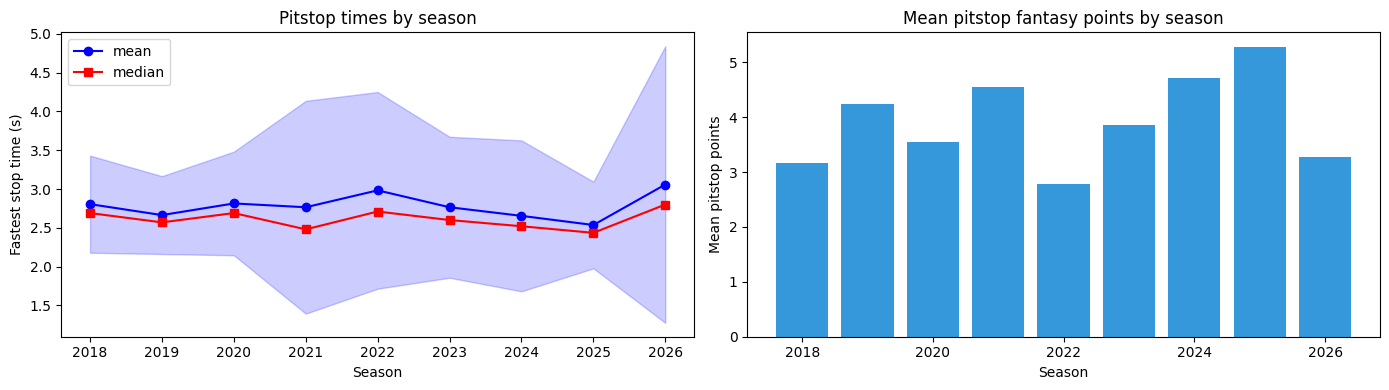

In [9]:
# season-level stats on fastest stop per constructor per race
season_stats = (
    constructor_best.groupby('season')['stationary_s']
    .agg(['mean', 'median', 'std', 'min'])
    .round(3)
)
print("Season-level stats (fastest stop per constructor per race):\n")
print(season_stats.to_string())

# points per season
season_pts = constructor_best.groupby('season')['pitstop_pts'].mean().round(2)
print(f"\nMean pitstop points per constructor per race by season:\n{season_pts.to_string()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(season_stats.index, season_stats['mean'], 'bo-', label='mean')
axes[0].plot(season_stats.index, season_stats['median'], 'rs-', label='median')
axes[0].fill_between(season_stats.index,
                     season_stats['mean'] - season_stats['std'],
                     season_stats['mean'] + season_stats['std'],
                     alpha=0.2, color='blue')
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Fastest stop time (s)')
axes[0].set_title('Pitstop times by season')
axes[0].legend()

axes[1].bar(season_pts.index, season_pts.values, color='#3498db')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Mean pitstop points')
axes[1].set_title('Mean pitstop fantasy points by season')

plt.tight_layout()
plt.show()

## Pitstop time distribution by constructor (2023-2026)

Box plots of fastest stop time per race, showing which teams are reliably fast vs variable.

C:\Users\gputs\AppData\Local\Temp\ipykernel_28128\1823744906.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=teams_ordered, patch_artist=True)


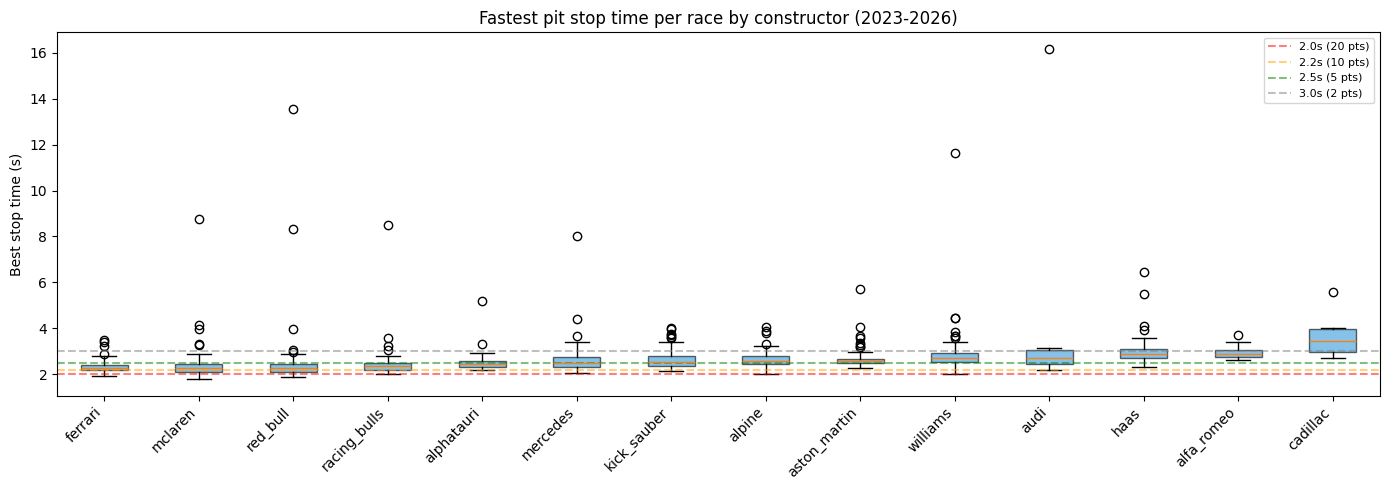


Team medians (2023-2026):
constructor_id
ferrari         2.270
mclaren         2.270
red_bull        2.270
racing_bulls    2.370
alphatauri      2.445
mercedes        2.490
kick_sauber     2.530
alpine          2.580
aston_martin    2.600
williams        2.720
audi            2.725
haas            2.880
alfa_romeo      2.885
cadillac        3.475


In [10]:
# filter to current-era teams with enough data
recent_best = constructor_best[constructor_best['season'] >= 2023].copy()

team_medians = recent_best.groupby('constructor_id')['stationary_s'].median().sort_values()
teams_ordered = team_medians.index.tolist()

fig, ax = plt.subplots(figsize=(14, 5))
data = [recent_best[recent_best['constructor_id'] == t]['stationary_s'].values for t in teams_ordered]
bp = ax.boxplot(data, labels=teams_ordered, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('#3498db')
    patch.set_alpha(0.6)
ax.axhline(2.0, color='red', linestyle='--', alpha=0.5, label='2.0s (20 pts)')
ax.axhline(2.2, color='orange', linestyle='--', alpha=0.5, label='2.2s (10 pts)')
ax.axhline(2.5, color='green', linestyle='--', alpha=0.5, label='2.5s (5 pts)')
ax.axhline(3.0, color='gray', linestyle='--', alpha=0.5, label='3.0s (2 pts)')
ax.set_ylabel('Best stop time (s)')
ax.set_title('Fastest pit stop time per race by constructor (2023-2026)')
ax.legend(fontsize=8)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTeam medians (2023-2026):")
print(team_medians.round(3).to_string())

## Modelling takeaways

Key findings for predicting constructor pitstop points:

1. **Rolling average of best stop time** is the most natural feature. Window of 5-8 races balances recency vs noise.
2. **Bracket scoring is nonlinear** - small time differences cross thresholds. This means predicting the raw time and then scoring it is better than predicting points directly.
3. **Fastest-stop bonus (+5)** is hard to predict - it's concentrated among top-tier pit crews but still noisy race to race.
4. **Team tiers are fairly stable** within a season - teams rarely jump more than one bracket. A team's rolling average bracket is a strong prior.
5. **Season trends** matter - overall times shift between seasons (regulation changes, tyre changes), so cross-season features should be normalised or use recent-only windows.